<a href="https://colab.research.google.com/github/PanditPranav/WildAlertModels_Circumstances/blob/main/notebooks/05_04102024_inference-predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, PretrainedConfig

import pandas as pd
import torch
import torch.nn.functional as F

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from datetime import datetime
# extract date object
today = datetime.now().date().strftime("%d-%m-%y")
# format date
print('Date String', today)

Date String 09-04-26


In [4]:
from pathlib import Path
model_dir = Path("/content/drive/MyDrive/WildAlertCOA/WildAlertCircumstancesExp")
data_dir = Path("/content/drive/MyDrive/WildAlertCOA/data/processed")
raw_data_dir = Path("/content/drive/MyDrive/WildAlertCOA/data/raw")
interim_data_dir = Path("/content/drive/MyDrive/WildAlertCOA/data/interim")

data = pd.read_parquet (raw_data_dir/"wildalert_circumstances_api.parquet")

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_dir/"checkpoint-38600/")
model = AutoModelForSequenceClassification.from_pretrained(model_dir/"checkpoint-38600/")
config = PretrainedConfig.from_pretrained(model_dir/"checkpoint-38600/")

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

You are using a model of type bert to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


In [6]:
sample = "White-fronted Amazon. found with illegal loggers. unknown, Illegal logging in Crooked Tree. Victoria confiscation while Nikki & Celeshia in OW doing checks"

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

Using device: cpu



In [8]:
#device = torch.device("cuda")
#model = model.to(device)

In [9]:
#?tokenizer

In [10]:
def _pre(text, device):
    tokens = tokenizer(text, return_tensors="pt")
    tokens = {k: v.to(device) for k,v in tokens.items()}
    return tokens

def _inf(model, tokens):
    out = model(**tokens)
    return out

def _post(out):
    probs = F.sigmoid(out.logits.squeeze().detach().cpu())
    preds = (probs > 0.5).int()
    labels = [config.id2label[idx] for idx, label in enumerate(preds) if label == 1.0]
    return labels

def infer(model, text):
    tokens = _pre(text, model.device)
    if (len(tokens['input_ids'][0]) <= 512):
        out = _inf(model, tokens)
        pred = _post(out)
        return pred
    else:
        return 'long or short text, working on the bug'

In [11]:
infer(model, sample)

['confiscation']

In [12]:
data.iloc[7335]

,7335
text,White-crowned Sparrow. Entangled - String / Ne...
terms,[Entrapped in netting / string / wire]


In [13]:
data.shape

(36315, 2)

In [14]:
pred_df = data[~data.text.isna()]
pred_df = pred_df[pred_df.text.str.len()>1]

In [15]:
%%time
predictions = []
for _,row in pred_df.iterrows():
    #print(row["text"])
    #print("actuals: ", row["terms"])
    pred = infer(model, row["text"])
    #print("predicts: ", pred)
    predictions.append(pred)
    if len(predictions)%1000 == 0:
        print(len(predictions))
    #print(len(predictions))
    #print("="*20)

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
CPU times: user 1h 23min 40s, sys: 6.79 s, total: 1h 23min 47s
Wall time: 1h 25min 32s


In [16]:
pred_df.iloc[358].text

'Virginia Opossum. the County was doing a smoke test - underneath of the house was filling with smoke, found opos. cat food'

In [17]:
pred_df.shape

(36315, 2)

In [ ]:
#aa = data[data.text.str.len() == data.text.str.len().max()].text.values[0]

In [18]:
infer(model, sample)

['confiscation']

In [19]:
len(predictions)

36315

In [ ]:
#predictions

In [20]:
pred_df.shape

(36315, 2)

In [21]:
pred_df['predictions'] = predictions

In [27]:
today

'09-04-26'

In [29]:
#pred_df.to_excel(raw_data_dir / f"predictions_{today}.xlsx")
pred_df.to_parquet(raw_data_dir / f"predictions_{today}.parquet")

In [30]:
pred_df['patient_id'] = pred_df.index
pred_df.set_index('patient_id', inplace = True)
pred_df.head()

,text,terms,predictions
patient_id,,,
0,"Mallard. In road, easy to catch, hit by car. ...",[Vehicle collision],[vehicle_collision]
1,Grey Fox. Orphan,[Orphan],[orphan]
2,Malay Spotted Dove. Cat attack,[Cat interaction],[cat_interaction]
3,"Mew Gull. Found on ground, in road, easy to ca...",[Vehicle collision],[vehicle_collision]
4,Common Merganser. Orphans,[Orphan],[orphan]


In [32]:
pred_df.terms.iloc[0]

array(['Vehicle collision'], dtype=object)

In [41]:
#import ast
#pred_df['terms'] = pred_df.terms.apply(ast.literal_eval)

In [36]:
#len(pred_df['terms'].explode())

In [37]:
from sklearn.metrics import multilabel_confusion_matrix
def add_one_hot(df, column):
    _df = df.copy()
    ohe = (pd.get_dummies(_df[column].apply(pd.Series).stack(), dtype="int")
             .groupby(level=0)
             .sum()
          )
    return pd.merge(_df, ohe, left_index=True, right_index=True)

In [38]:
pred_df.head()

,text,terms,predictions
patient_id,,,
0,"Mallard. In road, easy to catch, hit by car. ...",[Vehicle collision],[vehicle_collision]
1,Grey Fox. Orphan,[Orphan],[orphan]
2,Malay Spotted Dove. Cat attack,[Cat interaction],[cat_interaction]
3,"Mew Gull. Found on ground, in road, easy to ca...",[Vehicle collision],[vehicle_collision]
4,Common Merganser. Orphans,[Orphan],[orphan]


In [39]:
pd.get_dummies(pred_df['predictions'].apply(pd.Series).stack(), dtype="int").groupby(level = 0).sum()

,abduction_with_intent_of_rescue,animal_interaction,bicycle_collision,born_in_captivity,botanicals,bow_and_arrow,cat_interaction,collision,confiscation,cooking_oil_exposure,...,trapped_in_humane_/_cage_trap,trapped_in_leghold_/_trap_/_snare,tree_trimming,unauthorized_or_untrained_rehabilitation,undetermined,vehicle_collision,watercraft_collision,weather_event,wind_turbine_collision,window_/_wall_collision
patient_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36310,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36311,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36312,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
ydf_true = add_one_hot(pred_df, column='terms')
ydf_pred = add_one_hot(pred_df, column='predictions')
ydf_true.columns = ydf_true.columns.str.lower().str.replace(" ", "_")

In [42]:
ydf_true.shape

(36315, 81)

In [43]:
ydf_pred.shape

(36262, 74)

In [ ]:
ydf_true.head()

,text,terms,predictions,abduction_with_intent_of_rescue,animal_interaction,barbed_wire,bicycle_collision,born_in_captivity,botanicals,bow_and_arrow,...,trapped_in_humane_/_cage_trap,trapped_in_leghold_/_trap_/_snare,tree_trimming,unauthorized_or_untrained_rehabilitation,undetermined,vehicle_collision,watercraft_collision,weather_event,wind_turbine_collision,window_/_wall_collision
patient_id,,,,,,,,,,,,,,,,,,,,,
0,Southern Alligator Lizard. Found in green bin ...,"[Entrapped in litter / garbage, Garden / farm ...",[garden_/_farm_equipment_collision],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,"Unidentified Snake. Surrendered. 7 of 11, Cher...",[Confiscation],[confiscation],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Mallard. Unknown. DOVE LEWIS. was being attack...,[Same species interaction],[same_species_interaction],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Spotted Owl. Injury (plucked area/gash) on bac...,[Physical trauma],[physical_trauma],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Eastern Gray Squirrel. FELL. Tree was cut down,"[Tree trimming, Nest / Habitat disturbance or ...","[nest_/_habitat_disturbance_or_destruction, tr...",0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [44]:
ydf_true.index.nunique()

36315

In [45]:
ydf_true.head()

,text,terms,predictions,abduction_with_intent_of_rescue,animal_interaction,bicycle_collision,born_in_captivity,botanicals,bow_and_arrow,cat_interaction,...,tree_trimming,unauthorized_or_untrained_rehabilitation,undetermined,vehicle_collision,vehicle_collision,watercraft_collision,weather_event,wind_turbine_collision,window_/_wall_collision,window_/_wall_collision
patient_id,,,,,,,,,,,,,,,,,,,,,
0,"Mallard. In road, easy to catch, hit by car. ...",[Vehicle collision],[vehicle_collision],0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,Grey Fox. Orphan,[Orphan],[orphan],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Malay Spotted Dove. Cat attack,[Cat interaction],[cat_interaction],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,"Mew Gull. Found on ground, in road, easy to ca...",[Vehicle collision],[vehicle_collision],0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,Common Merganser. Orphans,[Orphan],[orphan],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
ydf_pred.shape

(36262, 74)

In [47]:
cases = ydf_pred.index.unique().tolist()
y = ydf_true.loc[cases]
y.shape

(36262, 81)

In [49]:
columns_list = ['abduction_with_intent_of_rescue',
 'animal_interaction',
 'bicycle_collision',
 'born_in_captivity',
 'botanicals',
 'bow_and_arrow',
 'cat_interaction',
 'collision',
 'confiscation',
 'cooking_oil_exposure',
 'displaced_from_nest',
 'disturbed_metabolic_rest',
 'dog_interaction',
 'domestic_animal_interaction',
 'dumped',
 'electrocution',
 'entrapment',
 'entrapped_in_building',
 'entrapped_in_chimney',
 'entrapped_in_fence',
 'entrapped_in_fishing_tackle',
 'entrapped_in_litter_/_garbage',
 'entrapped_in_netting_/_string_/_wire',
 'entrapped_in_storm_drain_/_sewer',
 'entrapped_in_vehicle',
 'entrapped_in_water',
 'fire_/_smoke',
 'friendly',
 'garden_/_farm_equipment_collision',
 'gas_flare',
 'grease_exposure',
 'grounded',
 'gunshot',
 'hand_held_object_collision',
 'illness',
 'inappropriate_human_intervention',
 'maladaptation_/_failure_to_thrive',
 'mating_injury',
 'nest_/_habitat_disturbance_or_destruction',
 'non-domestic_animal_interaction',
 'non-weapon_projectile',
 'nuisance_animal',
 'orphan',
 'paint_exposure',
 'pet',
 'petrochemical_exposure',
 'physical_trauma',
 'physical_trauma_by_unknown_cause',
 'plane_collision',
 'poisoned',
 'powerline_/_wire_collision',
 'referral_/_transfer',
 'same_species_interaction',
 'solar_panel_collision',
 'stranded',
 'surrender',
 'tar_exposure',
 'toxic_exposure',
 'toxin_exposure',
 'train_collision',
 'trapped_in_glue_trap',
 'trapped_in_humane_/_cage_trap',
 'trapped_in_leghold_/_trap_/_snare',
 'tree_trimming',
 'unauthorized_or_untrained_rehabilitation',
 'undetermined',
 'vehicle_collision',
 'watercraft_collision',
 'weather_event',
 'wind_turbine_collision',
 'window_/_wall_collision']

In [51]:
y[columns_list].shape

(36262, 78)

In [54]:
ydf_pred[columns_list].shape

(36262, 71)

In [55]:
ydf_pred = ydf_pred.reindex(columns=y[columns_list].columns, fill_value=0)

In [56]:
vis_arr  = multilabel_confusion_matrix(y[columns_list], ydf_pred[columns_list])
vis_arr

array([[[35150,    16],
        [    9,  1087]],

       [[35517,    25],
        [   38,   682]],

       [[36074,     1],
        [    2,   185]],

       [[36093,     0],
        [    2,   167]],

       [[36252,     0],
        [    0,    10]],

       [[36176,     0],
        [    0,    86]],

       [[33738,  2523],
        [    0,     1]],

       [[33730,    40],
        [    8,  2484]],

       [[36085,    12],
        [   13,   152]],

       [[35902,     4],
        [   10,   346]],

       [[35989,    16],
        [    8,   249]],

       [[34884,    72],
        [   64,  1242]],

       [[36131,     0],
        [    0,   131]],

       [[33768,    36],
        [   17,  2441]],

       [[34246,    25],
        [   20,  1971]],

       [[35991,    11],
        [   15,   245]],

       [[36125,     8],
        [    5,   124]],

       [[36031,    20],
        [   22,   189]],

       [[35841,   413],
        [    0,     8]],

       [[35815,    33],
        [   26,   388]],



In [57]:
# Calculate precision, recall and f1-score per label
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(y[columns_list], ydf_pred[columns_list], average=None)

In [58]:
# Print scores
labels = columns_list
for i in range(len(labels)):
    print(f'Label: {labels[i]}')
    print(f'Precision: {precision[i]:.3f}')
    print(f'Recall: {recall[i]:.3f}')
    print(f'F1-score: {f1[i]:.3f}\n')

Label: abduction_with_intent_of_rescue
Precision: 0.985
Recall: 0.992
F1-score: 0.989

Label: animal_interaction
Precision: 0.965
Recall: 0.947
F1-score: 0.956

Label: bicycle_collision
Precision: 0.995
Recall: 0.989
F1-score: 0.992

Label: born_in_captivity
Precision: 1.000
Recall: 0.988
F1-score: 0.994

Label: botanicals
Precision: 1.000
Recall: 1.000
F1-score: 1.000

Label: bow_and_arrow
Precision: 1.000
Recall: 1.000
F1-score: 1.000

Label: cat_interaction
Precision: 0.000
Recall: 1.000
F1-score: 0.001

Label: collision
Precision: 0.984
Recall: 0.997
F1-score: 0.990

Label: confiscation
Precision: 0.927
Recall: 0.921
F1-score: 0.924

Label: cooking_oil_exposure
Precision: 0.989
Recall: 0.972
F1-score: 0.980

Label: displaced_from_nest
Precision: 0.940
Recall: 0.969
F1-score: 0.954

Label: disturbed_metabolic_rest
Precision: 0.945
Recall: 0.951
F1-score: 0.948

Label: dog_interaction
Precision: 1.000
Recall: 1.000
F1-score: 1.000

Label: domestic_animal_interaction
Precision: 0.985


In [59]:
len(columns_list)

71

In [60]:
labels  = columns_list
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
def print_confusion_matrix(confusion_matrix, axes, class_label, class_names, fontsize=14):
    confusion_matrix = confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis]
    #print(confusion_matrix)
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )

    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt=".2f", cbar=False, ax=axes)
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    axes.set_ylabel('True label')
    axes.set_xlabel('Predicted label')
    axes.set_title(class_label)

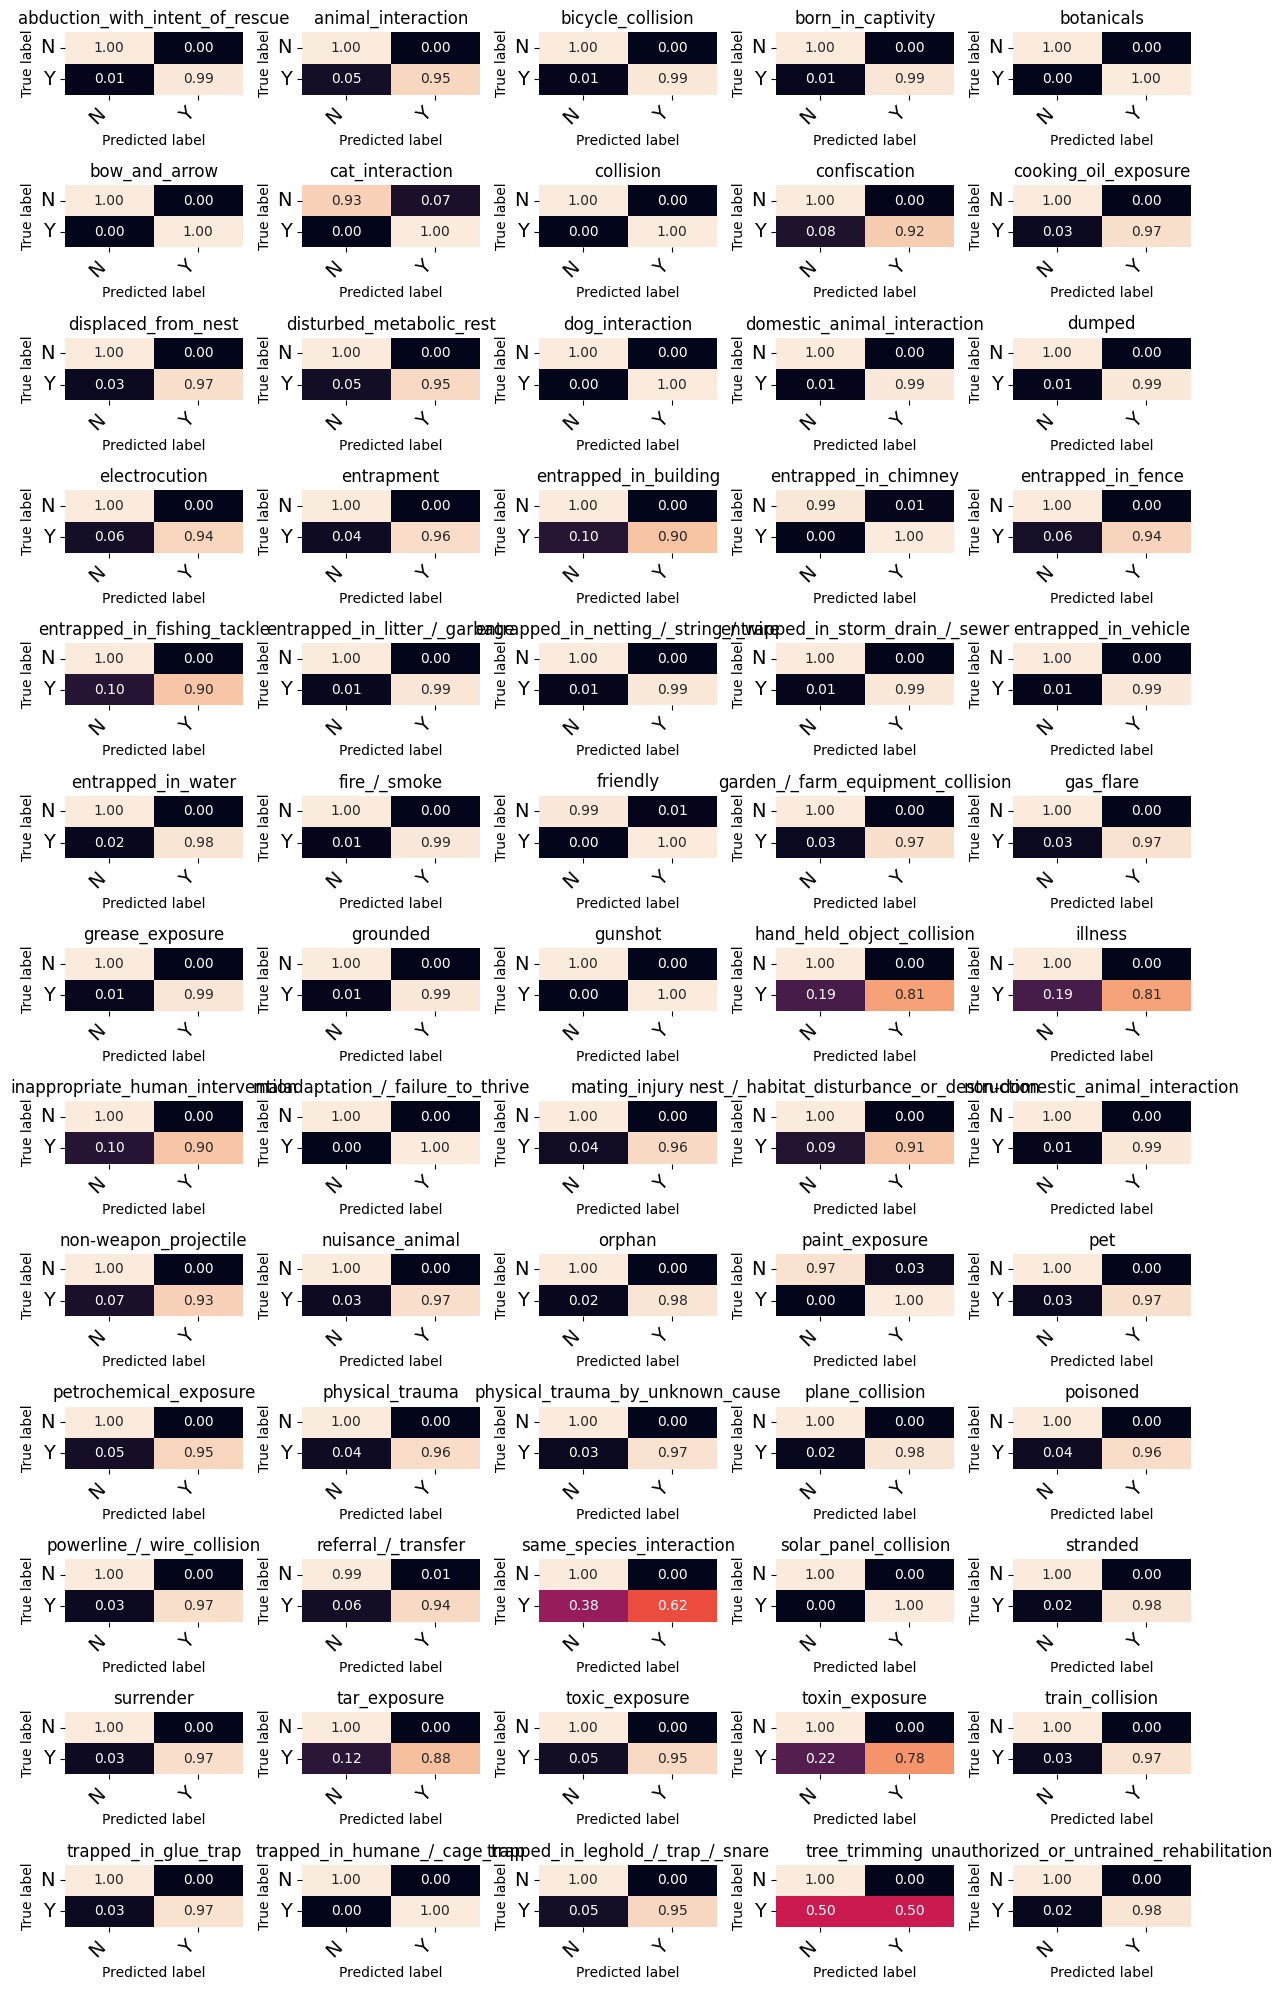

In [61]:
fig, ax = plt.subplots(13, 5, figsize=(12, 20))
for axes, cfs_matrix, label in zip(ax.flatten(), vis_arr, labels):
    print_confusion_matrix(cfs_matrix, axes, label, ["N", "Y"])

fig.tight_layout()
plt.savefig(raw_data_dir /f'confusion_matrix_{today}.png', dpi = 600)
plt.show()

In [62]:
import sklearn.metrics as skm
#import mlmc

In [ ]:
#import os
#os.getcwd()

In [66]:
%run "/content/drive/MyDrive/WildAlertCOA/mlcm.py"

<Figure size 640x480 with 0 Axes>

### Computing confusion matrix using 'MLCM"

In [67]:
conf_mat,normal_conf_mat = cm(y[columns_list].values, ydf_pred[columns_list].values)
print('\nRaw confusion Matrix:')
print(conf_mat)
print('\nNormalized confusion Matrix (%):')
print(normal_conf_mat)

MLCM has one extra row (NTL) and one extra column (NPL).        
Please read the following paper for more information:
        Heydarian et al., MLCM: Multi-Label Confusion Matrix, IEEE Access,2022        
To skip this message, please add parameter "print_note=False"
        e.g., conf_mat,normal_conf_mat = mlcm.cm(label_true,label_pred,False)

Raw confusion Matrix:
[[1087    0    0 ...    0    0    1]
 [   0  682    0 ...    8    3    4]
 [   0    0  185 ...    0    0    1]
 ...
 [   0    0    0 ...    1    1    0]
 [   0    0    0 ... 1243 1274    3]
 [   0    0    0 ...    0    0    0]]

Normalized confusion Matrix (%):
[[95.  0.  0. ...  0.  0.  0.]
 [ 0. 88.  0. ...  1.  0.  1.]
 [ 0.  0. 92. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... 50. 50.  0.]
 [ 0.  0.  0. ... 47. 48.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]


In [68]:
processed_categories = []
for category in columns_list:
    category = category.replace('_disease', '')
    category = category.replace('_', ' ')
    category = category.capitalize()
    processed_categories.append(category)
columns_list
y_lables  = processed_categories + ['No True Lables']
x_lables  = processed_categories + ['No Predicted Label']

ValueError: The number of FixedLocator locations (79), usually from a call to set_ticks, does not match the number of labels (72).

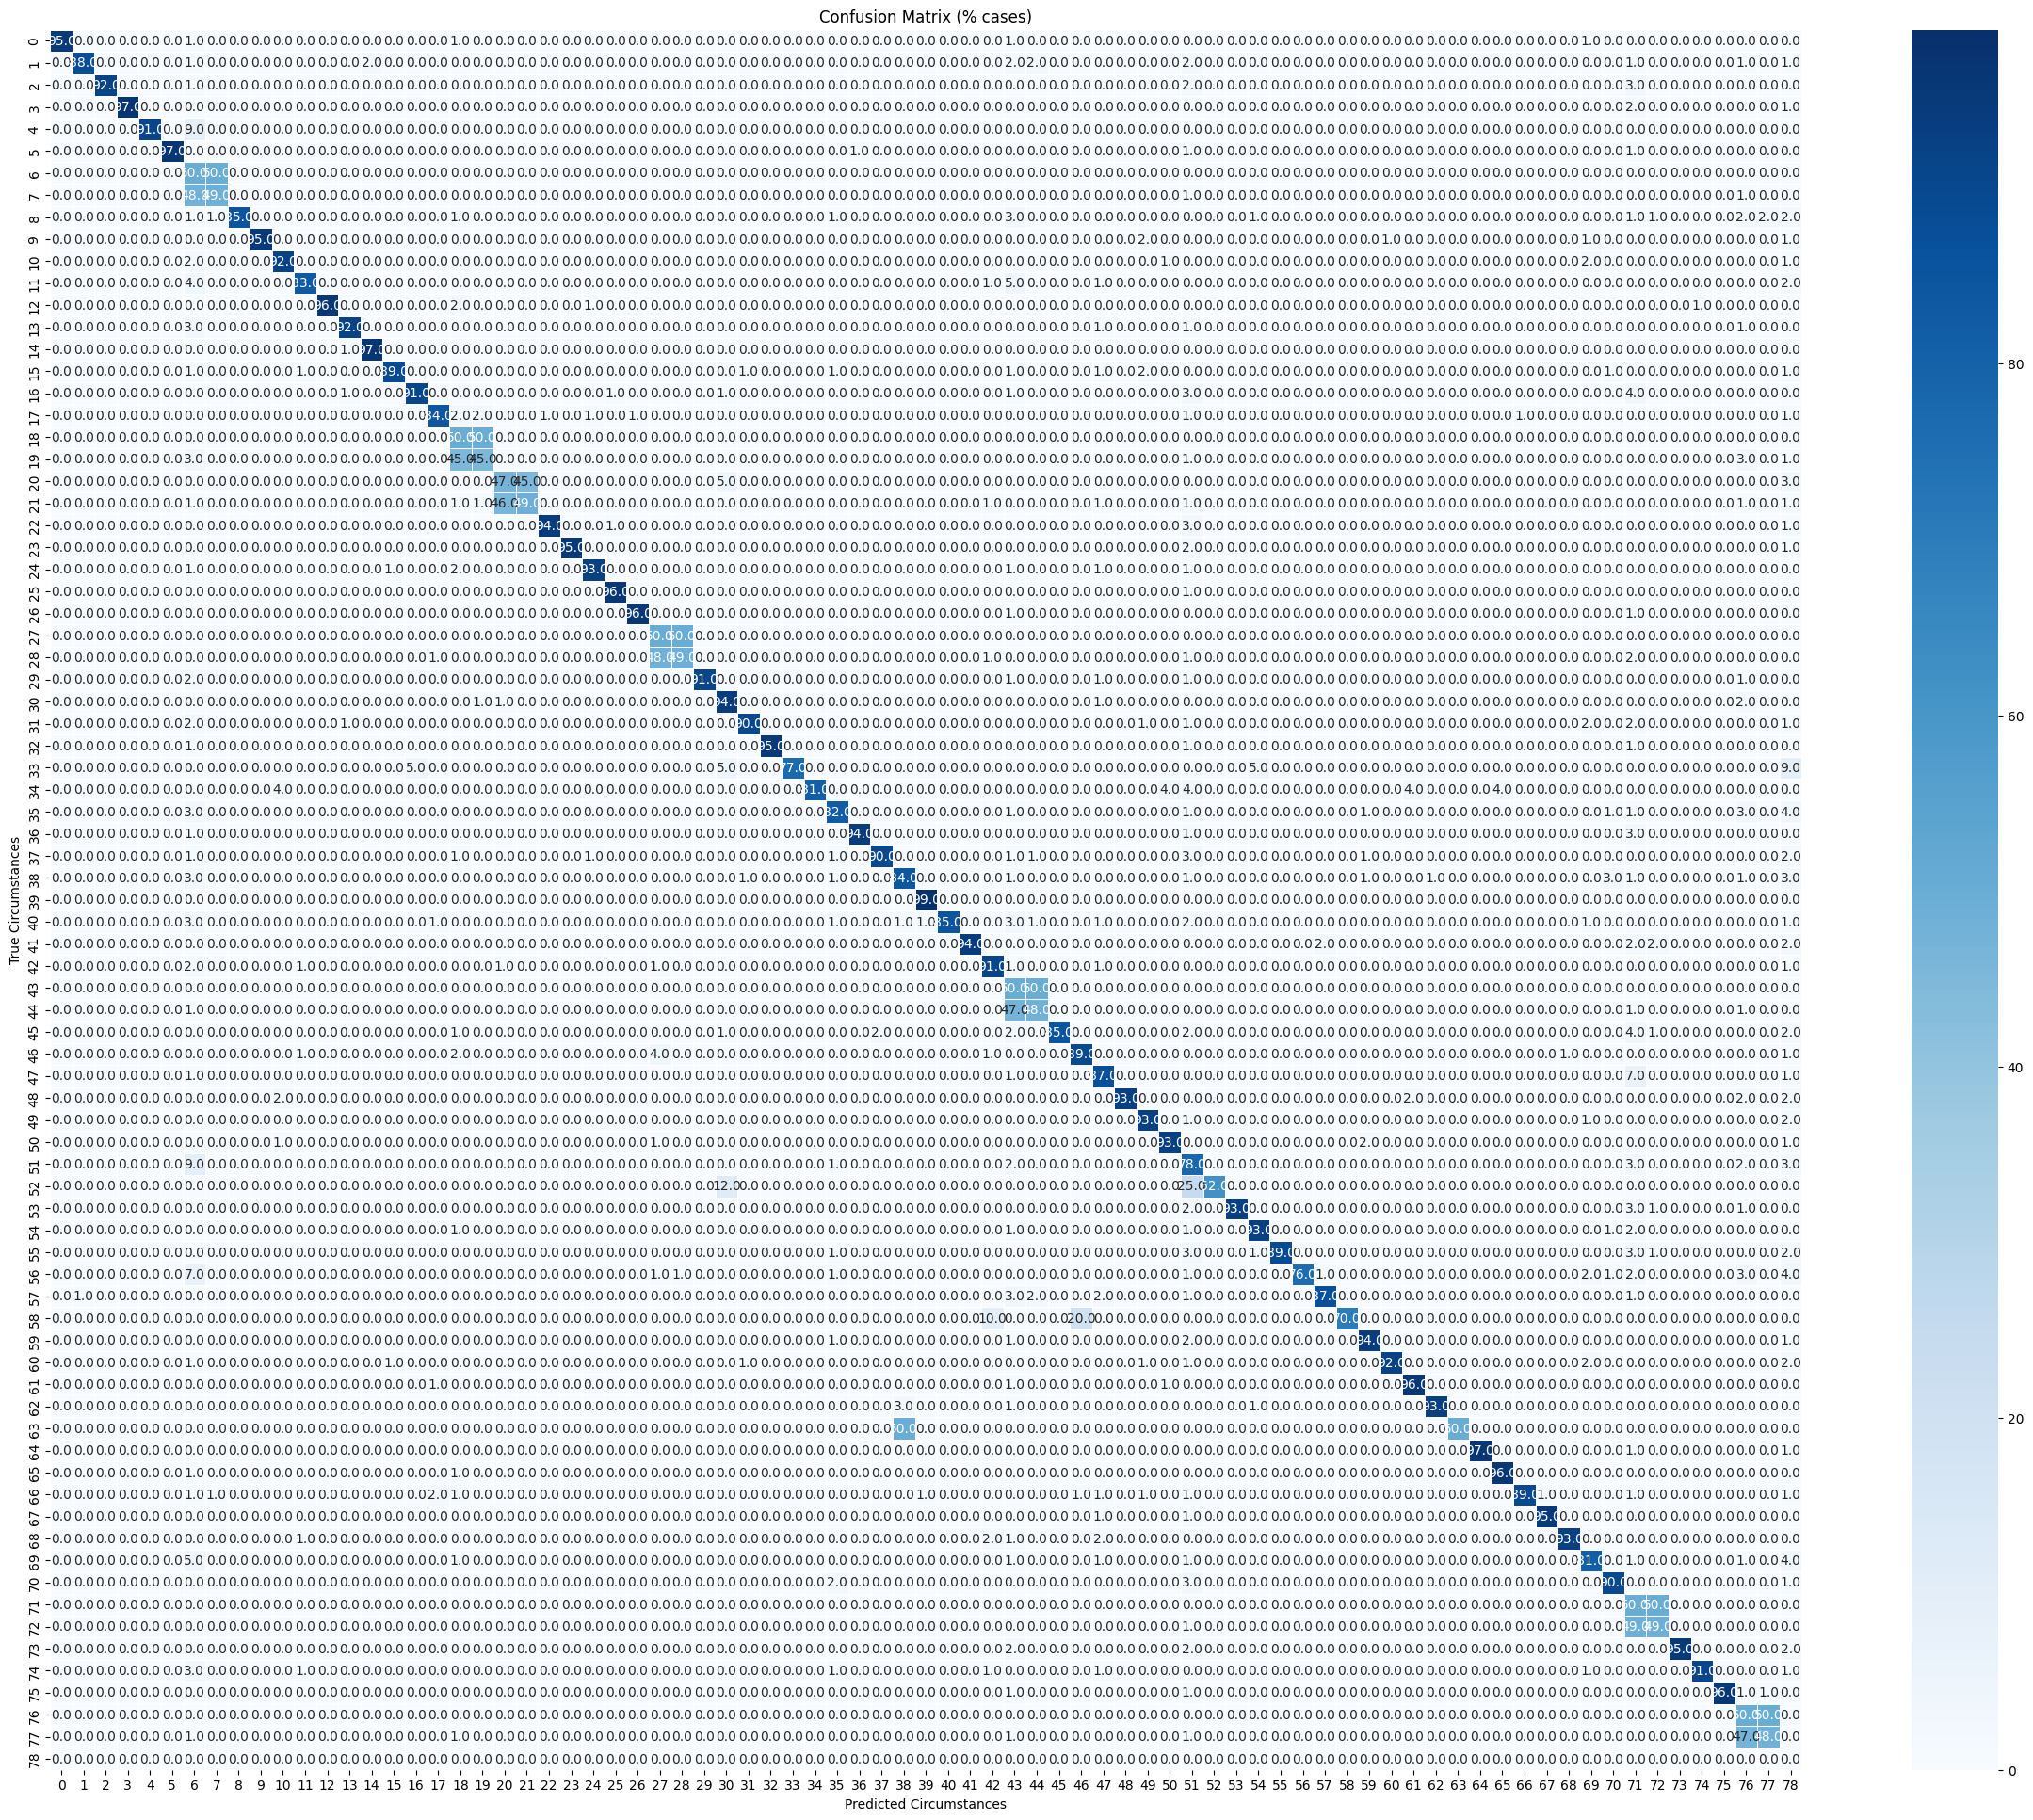

In [69]:
# Create the heatmap
plt.figure(figsize=(30,24))
ax = sns.heatmap(normal_conf_mat,
                cmap="Blues",
                annot=True,
                fmt=".1f",
                linewidths=.5)

# Customize the plot
ax.set_title("Confusion Matrix (% cases)")
ax.set_xlabel("Predicted Circumstances")
ax.set_ylabel("True Circumstances")
# Set x-axis tick labels
ax.set_xticklabels(x_lables, fontsize=10, rotation = 90)

# Set y-axis tick labels
ax.set_yticklabels(y_lables, fontsize=10, rotation = 0)
plt.tight_layout()
plt.savefig(raw_data_dir /f'Confusion_matrix_normalized_{today}.png', dpi = 600)
plt.show()

ValueError: The number of FixedLocator locations (79), usually from a call to set_ticks, does not match the number of labels (72).

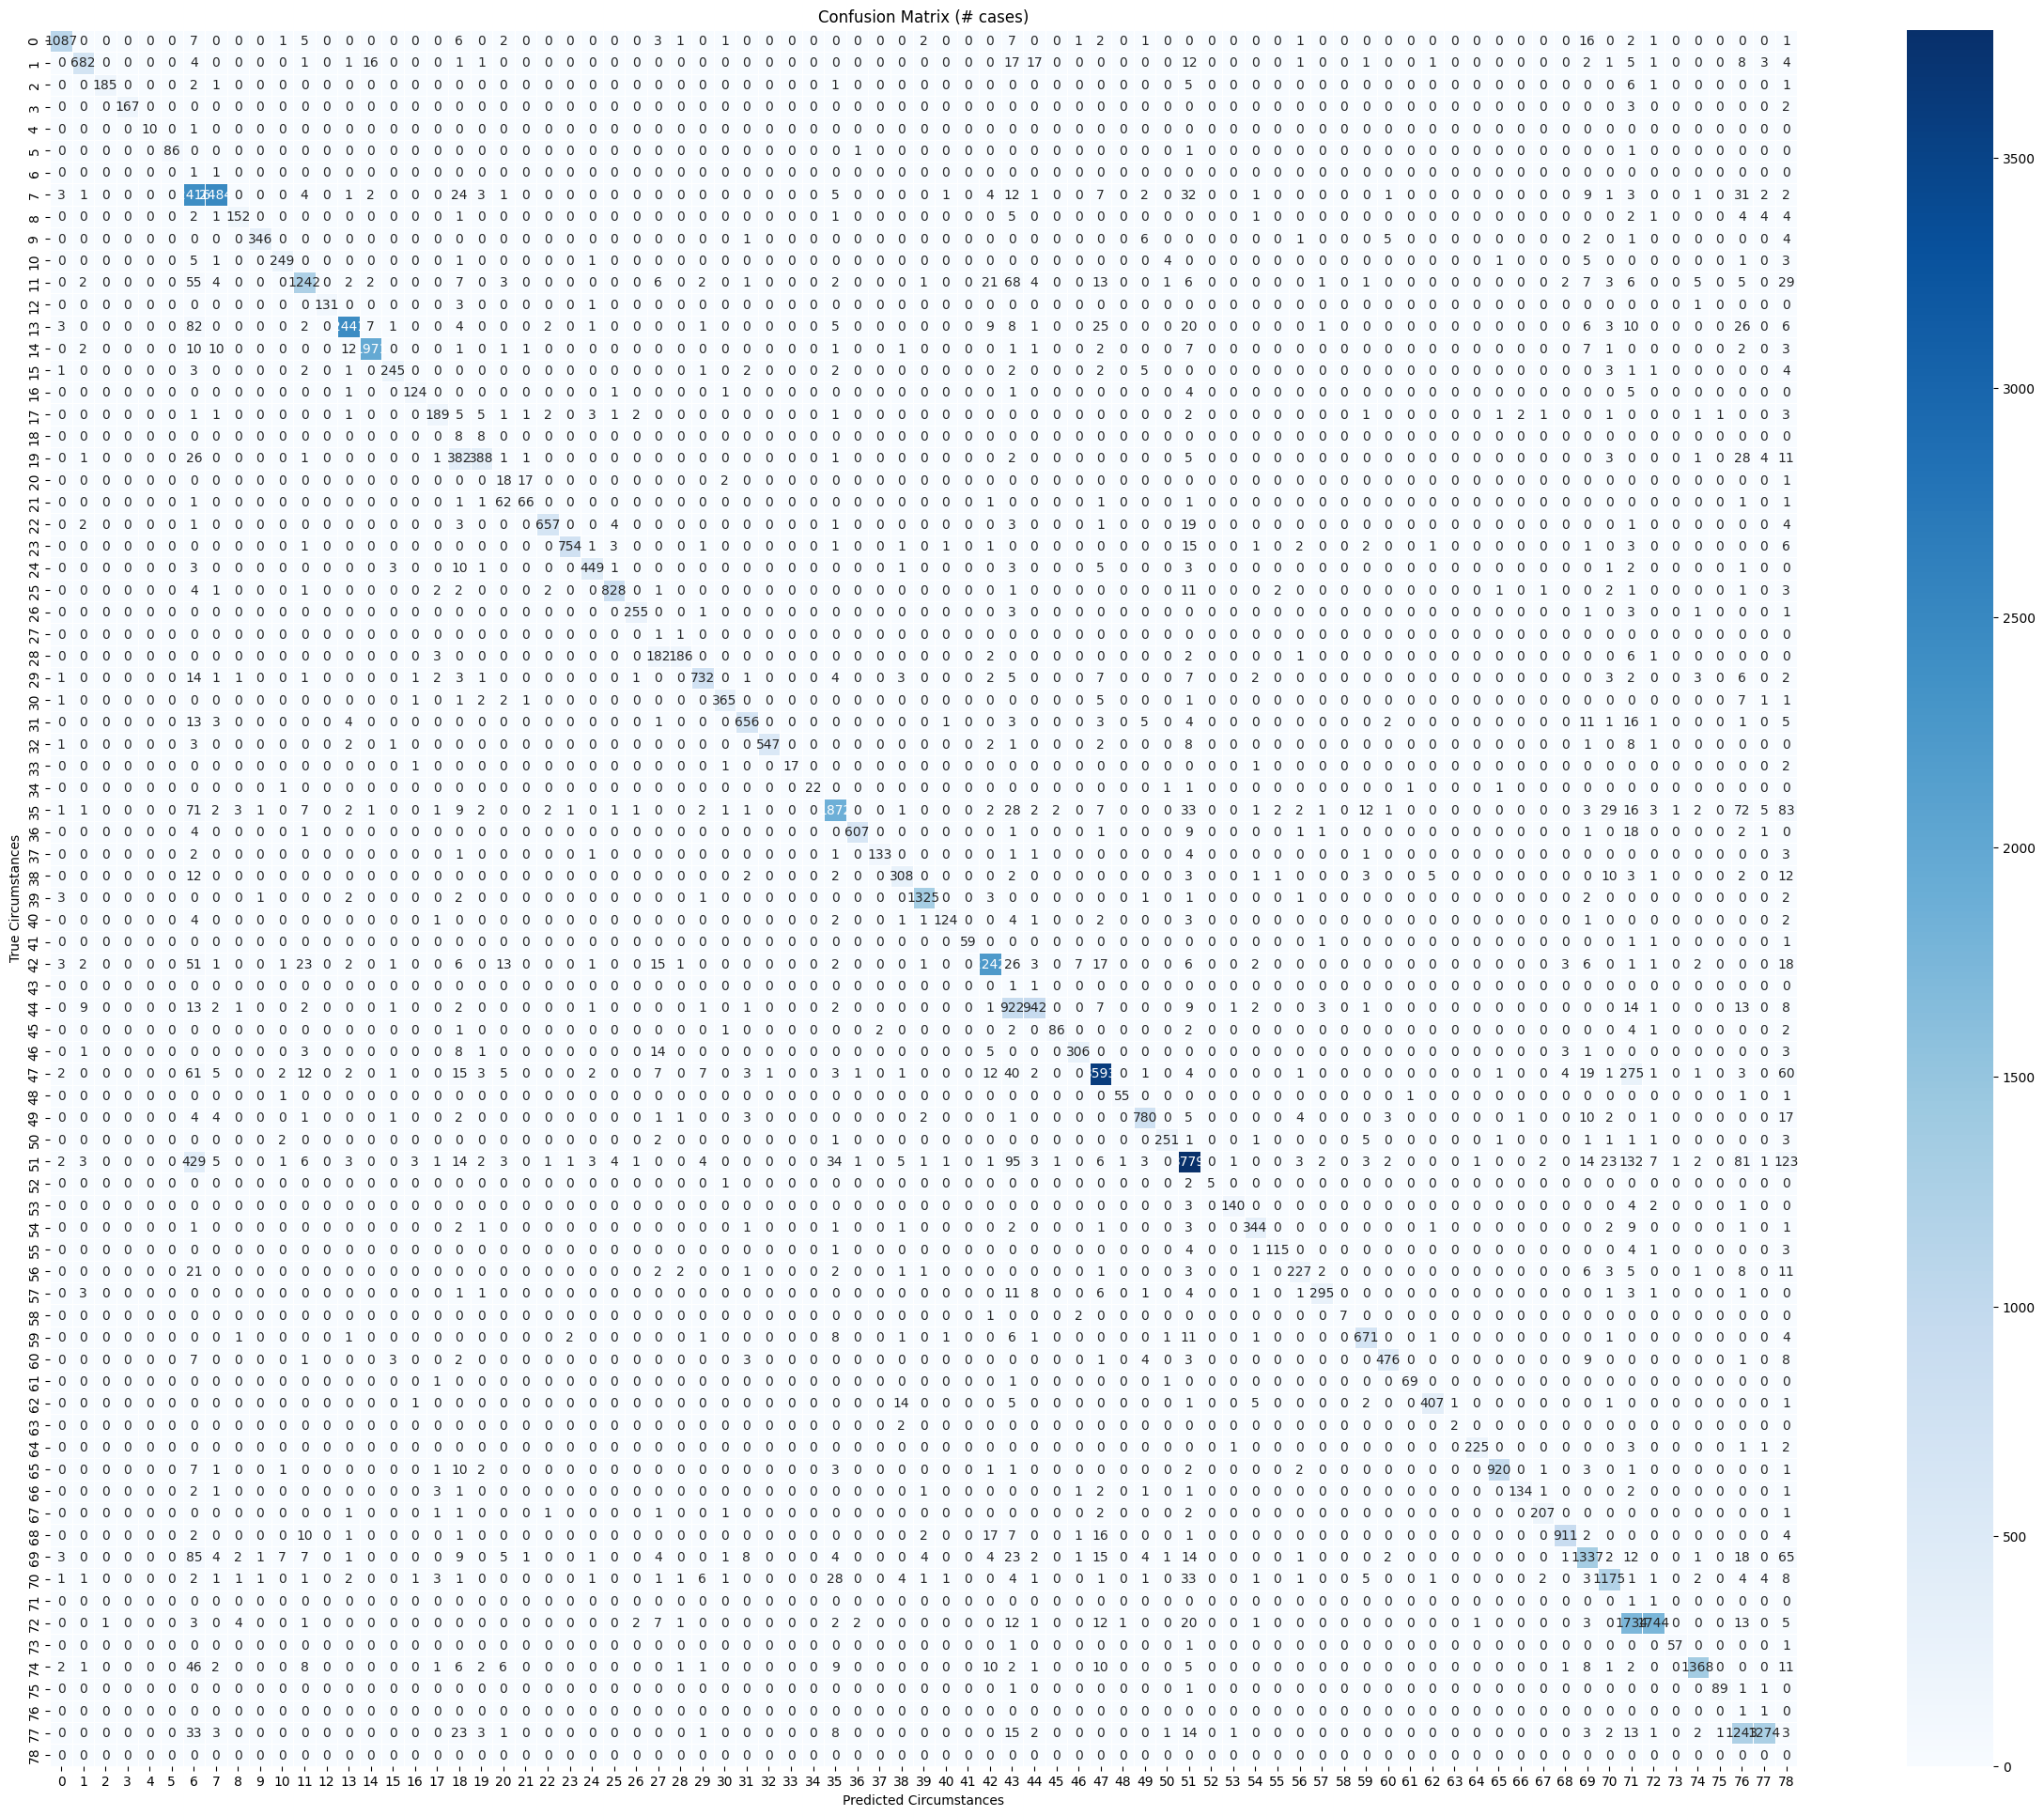

In [70]:
# Create the heatmap
plt.figure(figsize=(30,24))
ax = sns.heatmap(conf_mat,
                cmap="Blues",
                annot=True,
                fmt=".0f",
                linewidths=.5)

# Customize the plot
ax.set_title("Confusion Matrix (# cases)")
ax.set_xlabel("Predicted Circumstances")
ax.set_ylabel("True Circumstances")
# Set x-axis tick labels
ax.set_xticklabels(x_lables, fontsize=10, rotation = 90)

# Set y-axis tick labels
ax.set_yticklabels(y_lables, fontsize=10, rotation = 0)
plt.tight_layout()
plt.savefig(raw_data_dir /f'Confusion_matrix_raw_{today}.png', dpi = 600)
plt.show()

## Scores using MLCM

In [71]:
one_vs_rest = stats(conf_mat)

[[[45318    27]
  [   60  1087]]

 [[45723    29]
  [   97   682]]

 [[46220     1]
  [   17   185]]

 [[46238     0]
  [    5   167]]

 [[46395     0]
  [    1    10]]

 [[46319     0]
  [    3    86]]

 [[46404  3513]
  [    1     1]]

 [[43921    55]
  [ 2570  2484]]

 [[46253    13]
  [   26   152]]

 [[46059     4]
  [   20   346]]

 [[46156    17]
  [   22   249]]

 [[45163   101]
  [  259  1242]]

 [[46274     0]
  [    5   131]]

 [[43964    42]
  [  223  2441]]

 [[44434    28]
  [   63  1971]]

 [[46160    12]
  [   30   245]]

 [[46281     8]
  [   13   124]]

 [[46216    21]
  [   37   189]]

 [[46397   572]
  [    8     8]]

 [[46017    39]
  [  468   388]]

 [[46387   106]
  [   20    18]]

 [[46339    22]
  [   70    66]]

 [[45748    10]
  [   39   657]]

 [[45651     4]
  [   41   754]]

 [[45956    17]
  [   34   449]]

 [[45577    15]
  [   36   828]]

 [[46150     7]
  [   10   255]]

 [[46404   247]
  [    1     1]]

 [[46219     9]
  [  197   186]]

 [[45673    30

/content/drive/MyDrive/WildAlertCOA/mlcm.py:207: RuntimeWarning: invalid value encountered in divide
  recall = tp/(tp+fn)


In [72]:
one_vs_rest = stats(conf_mat, False)


       class#     precision        recall      f1-score        weight

            0          0.98          0.95          0.96          1147
            1          0.96          0.88          0.92          779
            2          0.99          0.92          0.95          202
            3          1.00          0.97          0.99          172
            4          1.00          0.91          0.95          11
            5          1.00          0.97          0.98          89
            6          0.00          0.50          0.00          2
            7          0.98          0.49          0.65          5054
            8          0.92          0.85          0.89          178
            9          0.99          0.95          0.97          366
            10          0.94          0.92          0.93          271
            11          0.92          0.83          0.87          1501
            12          1.00          0.96          0.98          136
            13          0.98 